In [76]:
!pip install pandas langchain_core langchain_text_splitters langchain_chroma langchain_huggingface

In [77]:
from typing import Annotated
from langchain_core.tools import tool
import pandas as pd
import os
import requests

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

import json
from pathlib import Path
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

### RAG

In [78]:
# ── RAG config ────────────────────────────────────────────────────────────────
PARSED_PAGES_PATH = Path("parsed_pages.json")
PERSIST_DIRECTORY = "./chroma_db_canada_travel"
COLLECTION_NAME   = "canada_travel_advisories"
LOCAL_EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
CHUNK_SIZE        = 700
CHUNK_OVERLAP     = 120
DEFAULT_TOP_K     = 4

# ── Vector store (built/loaded once) ──────────────────────────────────────────
def _get_embeddings():
    return HuggingFaceEmbeddings(model_name=LOCAL_EMBED_MODEL)

def _pages_to_documents(pages):
    docs = []
    for page in pages:
        dest    = page["destination"]
        risk    = page["risk_level"]
        url     = page["url"]
        title   = page["title"]
        updated = page.get("last_updated", "Unknown")
        for section in page.get("sections", []):
            heading = section.get("heading", "Unknown")
            text    = section.get("text", "")
            if len(text) < 80:
                continue
            content = f"Destination: {dest}\nRisk level: {risk}\nSection: {heading}\n\n{text}"
            docs.append(Document(
                page_content=content,
                metadata={
                    "source":        url,
                    "url":           url,
                    "title":         title,
                    "destination":   dest,
                    "risk_level":    risk,
                    "last_updated":  updated,
                    "section_title": heading,
                },
            ))
    return docs

def _build_or_load_vectorstore():
    embeddings = _get_embeddings()
    if Path(PERSIST_DIRECTORY).exists():
        print(f"[RAG] Loading existing vector store from {PERSIST_DIRECTORY}")
        return Chroma(
            collection_name=COLLECTION_NAME,
            persist_directory=PERSIST_DIRECTORY,
            embedding_function=embeddings,
        )
    print(f"[RAG] Building vector store from {PARSED_PAGES_PATH} ...")
    pages    = json.loads(PARSED_PAGES_PATH.read_text())
    raw_docs = _pages_to_documents(pages)
    splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
    chunks   = splitter.split_documents(raw_docs)
    print(f"[RAG] {len(pages)} pages, {len(raw_docs)} docs, {len(chunks)} chunks")
    vs = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=PERSIST_DIRECTORY,
        collection_name=COLLECTION_NAME,
    )
    print("[RAG] Vector store built and persisted.")
    return vs

_vectorstore = _build_or_load_vectorstore()


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4271.90it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[RAG] Loading existing vector store from ./chroma_db_canada_travel


### Tools

In [79]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 1 — RAG: Travel advisory lookup
# Used by: rag_agent, visa_checker_agent
# ─────────────────────────────────────────────────────────────────────────────
@tool
def retrieve_travel_advisory(query: str) -> str:
    """Search the Government of Canada travel-advisory knowledge base.

    Use this for: risk levels, entry/exit requirements, health precautions,
    safety warnings, local laws, emergency contacts, and travel readiness.

    Args:
        query: Natural-language question or keywords about a destination.

    Returns:
        Relevant excerpts from official Canadian travel advisories with
        destination, section, risk level, last-updated date, and source URL.
    """
    docs = _vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": DEFAULT_TOP_K, "fetch_k": DEFAULT_TOP_K * 2, "lambda_mult": 0.5},
    ).invoke(query)

    if not docs:
        return "No relevant travel advisory information found."

    parts = []
    for i, doc in enumerate(docs, 1):
        m       = doc.metadata
        dest    = m.get("destination", "Unknown")
        section = m.get("section_title", "Unknown")
        risk    = m.get("risk_level", "Unknown")
        updated = m.get("last_updated", "Unknown")
        url     = m.get("url", "")
        parts.append(
            f"[{i}] {dest} - {section}\n"
            f"Risk level: {risk} | Last updated: {updated}\n"
            f"Source: {url}\n\n"
            f"{doc.page_content}"
        )
    return "\n\n---\n\n".join(parts)


print("Tools defined: retrieve_travel_advisory")


Tools defined: retrieve_travel_advisory, search_attractions, get_directions, find_restaurants


### Initializing the LLM

In [ ]:
from typing import Annotated, Optional
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

class AgentState(TypedDict):
    """Shared state threaded through every node in the travel agent graph."""

    # Conversation history — append-only via add_messages reducer
    messages: Annotated[list, add_messages]

    # Supervisor routing
    intent:                 Optional[str]   # rag | vaccine_checker | visa_checker | appointment_booker | out_of_scope
    needs_reformulation:    Optional[bool]  # True when query is ambiguous
    clarification_question: Optional[str]   # Clarification to send back to user

    # Visa checker multi-turn slots
    visa_destination:  Optional[str]   # Country user wants to visit
    visa_passport:     Optional[str]   # User's passport / citizenship
    visa_duration:     Optional[str]   # Intended length of stay
    visa_purpose:      Optional[str]   # tourism | business | study | transit

    # Appointment booking multi-turn slots
    appt_service:      Optional[str]   # visa_application | passport_renewal | travel_consult
    appt_location:     Optional[str]   # City/office location
    appt_date:         Optional[str]   # Preferred date
    appt_name:         Optional[str]   # User full name
    appt_confirmed:    Optional[bool]  # True once booking is simulated

llm = ChatOpenAI(
    model="qwen3-30b-a3b-fp8",
    base_url=os.getenv("QWEN_API_BASE_URL"),
    openai_api_key="1006174042",
    temperature=0.9
)


### Testing the LLM Connection

In [81]:
# Quick LLM connectivity test
response = llm.invoke("Say 'LLM connection successful' and nothing else.")
print(response.content)



LLM connection successful


### Creating LLM Agents

In [102]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

# ── Supervisor agent ──────────────────────────────────────────────────────────
with open("prompts/supervisor_prompt.md", "r") as f:
    supervisor_prompt = f.read()

supervisor_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=supervisor_prompt,
)

# ── Travel Advisor agent ─────────────────────────────────────────────────────────────────
# Answers travel safety, risk, and health questions from the knowledge base.
with open("prompts/travel_advisor_prompt.md", "r") as f:
    rag_prompt = f.read()

travel_advisor_agent = create_agent(
    model=llm,
    tools=[retrieve_travel_advisory],
    system_prompt=rag_prompt,
)

# ── Visa Checker agent (multi-turn) ───────────────────────────────────────────
# Collects passport, destination, duration, purpose then returns visa guidance.
with open("prompts/visa_checker_prompt.md", "r") as f:
    visa_prompt = f.read()

visa_checker_agent = create_agent(
    model=llm,
    tools=[retrieve_travel_advisory],
    system_prompt=visa_prompt,
)

# ── Appointment Booking agent (multi-turn) ────────────────────────────────────
# Collects service, location, date, name then simulates a booking confirmation.
with open("prompts/appointment_booking_prompt.md", "r") as f:
    appt_prompt = f.read()

appointment_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=appt_prompt,
)

print("All agents created successfully.")


All agents created successfully.


### Building the Agentic Architecture

#### Adding Routing Functions

In [103]:
import json as _json, re
from langchain_core.messages import AIMessage, HumanMessage

def _extract_json(text: str) -> dict:
    """Pull the first JSON object out of an LLM response string."""
    match = re.search(r"\{.*?\}", text, re.DOTALL)
    if match:
        try:
            return _json.loads(match.group())
        except _json.JSONDecodeError:
            pass
    return {}

def route_supervisor(state: AgentState) -> str:
    """Read the supervisor's last AIMessage and route to the correct sub-agent."""
    ai_msgs = [m for m in state["messages"] if isinstance(m, AIMessage)]
    if not ai_msgs:
        return "travel_advisor"

    parsed = _extract_json(ai_msgs[-1].content)
    intent = parsed.get("intent", "rag")

    mapping = {
        "rag":                 "travel_advisor",
        "visa_checker":        "visa_checker",
        "appointment_booker":  "appointment_booker",
        "out_of_scope":        END,
    }
    return mapping.get(intent, "RAG")

print("Routing function defined.")


Routing function defined.


#### Creating Graph Nodes

In [104]:
def make_subagent_node(agent):
    """Wrap a sub-agent so it only sees the latest HumanMessage, not supervisor output."""
    def node(state: AgentState):
        human_msgs = [m for m in state["messages"] if isinstance(m, HumanMessage)]
        clean_state = {"messages": [human_msgs[-1]]}
        return agent.invoke(clean_state)
    return node

graph = StateGraph(AgentState)
graph.add_node("supervisor",          supervisor_agent)
graph.add_node("travel_advisor",                 make_subagent_node(travel_advisor_agent))
graph.add_node("visa_checker",        make_subagent_node(visa_checker_agent))
graph.add_node("appointment_booker",  make_subagent_node(appointment_agent))
print("Graph nodes constructed successfully.")


Graph nodes constructed successfully.


#### Creating Graph Edges

In [105]:
graph.add_edge(START, "supervisor")

graph.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {
        "travel_advisor":                "travel_advisor",
        "visa_checker":       "visa_checker",
        "appointment_booker": "appointment_booker",
        END:                  END,
    },
)

for node in ("travel_advisor", "visa_checker", "appointment_booker"):
    graph.add_edge(node, END)

print("Graph edges added successfully.")


Graph edges added successfully.


### Visualizing Graph

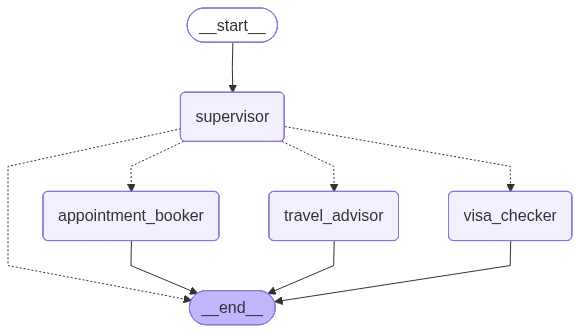

In [106]:
model = graph.compile(checkpointer=checkpointer)
model

### Sample Query Test

In [107]:
from langchain_core.messages import HumanMessage, AIMessage

def chat(query: str, thread_id: str = "test") -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = model.invoke({"messages": [HumanMessage(content=query)]}, config=config)
    ai_msgs = [m for m in result["messages"] if isinstance(m, AIMessage) and m.content and m.content.strip()]
    return ai_msgs[-1].content if ai_msgs else "(no response)"

test_queries = [
    ("travel_advisor",         "What is the travel risk level for Brazil?"),
    ("travel_advisor",         "What entry requirements does France have for Canadians?"),
    ("Vaccine",     "What vaccines do I need before travelling to Ghana?"),
    ("Visa",        "Do I need a visa to visit Australia as a Canadian citizen?"),
    ("Appointment", "I need to book a visa application appointment in Toronto."),
    ("OOS",         "What is the capital of France?"),
]

for label, query in test_queries:
    print(f"\n{'='*60}")
    print(f"[{label}] {query}")
    print("-"*60)
    print(chat(query, thread_id=label))



[travel_advisor] What is the travel risk level for Brazil?
------------------------------------------------------------


The Government of Canada advises **Exercise a high degree of caution** for travel to Brazil [Brazil travel advice - Transportation] [Brazil travel advice - Adventure travel] [Brazil travel advice - Border areas - Avoid non-essential travel] [Brazil travel advice - Rainy seasons]. 

This risk level applies to various aspects of travel, including transportation, adventure activities, border areas, and rainy season conditions. The advisory was last updated on March 24, 2026. For specific details, refer to the official pages on [travel.gc.ca](https://travel.gc.ca/destinations/brazil). 

Always verify with the official site for the most current information before traveling.

[travel_advisor] What entry requirements does France have for Canadians?
------------------------------------------------------------


Canadian citizens do not require a visa for short visits to Fr

### Interactive Chat

In [110]:
from langchain_core.messages import HumanMessage, AIMessage

# ── Change this to any query you want to test ─────────────────────────────────
query = "Is Iran a safe country to visit?"
# ─────────────────────────────────────────────────────────────────────────────

config = {"configurable": {"thread_id": "interactive"}}
result = model.invoke({"messages": [HumanMessage(content=query)]}, config=config)

ai_msgs = [m for m in result["messages"] if isinstance(m, AIMessage) and m.content and m.content.strip()]
response = ai_msgs[-1].content if ai_msgs else "(no response)"

print(f"You: {query}")
print()
print(f"Agent: {response}")


You: Is Iran a safe country to visit?

Agent: 

I do not have specific information about Iran in the provided context. The retrieved data pertains to **Azerbaijan**, which includes warnings about regional hostilities, air travel, and general caution. For accurate and destination-specific advice about Iran, I recommend checking the official [Travel Advice for Iran](https://travel.gc.ca/destinations/iran) on travel.gc.ca. 

Always verify the latest updates directly from the source for safety-critical information.
